In [2]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification, make_moons, make_blobs
from sklearn.metrics import accuracy_score, roc_curve, auc, ConfusionMatrixDisplay, confusion_matrix

# Generate dataset

In [3]:
X, y = make_classification( n_samples=2502,
                            random_state=259202,
                            n_features=2,
                            n_informative=2,
                            n_redundant=0,
                            n_repeated=0,
                            class_sep=2)
Xm, ym = make_moons(n_samples=2502, random_state=259202, noise=0.1)

In [4]:
def plot_data(X, y, title=""):
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)
    plt.title(title)
    plt.show()

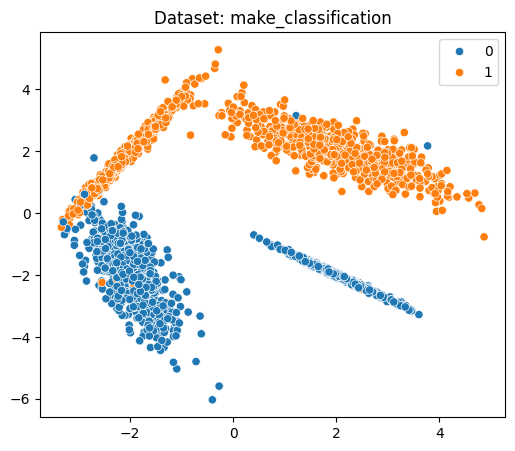

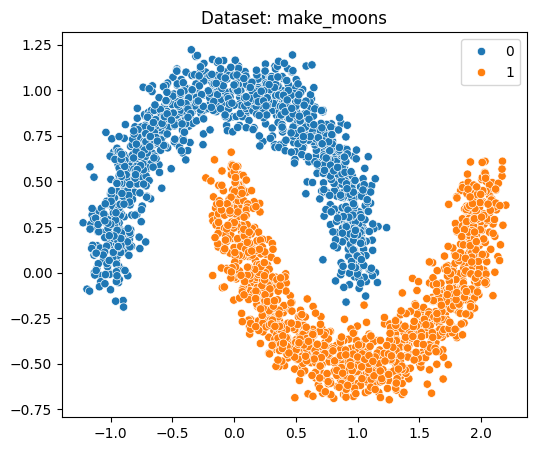

In [5]:
plot_data(X,y,"Dataset: make_classification")
plot_data(Xm,ym,"Dataset: make_moons")

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=295202)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(Xm, ym, random_state=295202)

In [15]:
def plot_decision_boundary(X, y, model, title=""):
    h = 0.05
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    pts = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(pts)

    Z = Z.reshape(xx.shape)

    # decition boundary
    plt.contourf(xx, yy, Z, alpha=0.3)

    # decision line
    plt.contour(xx, yy, Z, colors='k', linewidths=1)

    scatter = plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')

    plt.legend(*scatter.legend_elements(), loc="upper right", title="Classes")
    plt.title(title)
    plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
    plt.show()

# Neuron 

In [16]:
class Neuron:
    def __init__(self, input_dim, lr=0.1, activation='sigmoid'):
        self.w = np.random.randn(input_dim + 1)
        self.lr = lr
        self.activation = activation
        
    def _add_bias(self, X):
        return np.c_[X, np.ones(X.shape[0])]
    
    def _activation(self, s):
        if self.activation == 'sigmoid':
            return 1 / (1 + np.exp(-s))
        raise NotImplementedError
    
    def _activation_derivative(self, s):
        if self.activation == 'sigmoid':
            sig = self._activation(s)
            return sig * (1 - sig)
        raise NotImplementedError
    
    def predict(self, X):
        X_ = self._add_bias(X)
        s = X_ @ self.w
        y = self._activation(s)
        return (y > 0.5).astype(int)
    
    def predict_proba(self, X):
        X_ = self._add_bias(X)
        return self._activation(X_ @ self.w)
    
    def fit(self, X, y, epochs=100):
        X_ = self._add_bias(X)
        for epoch in range(epochs):
            for xi, ti in zip(X_, y):
                s = xi @ self.w
                yi = self._activation(s)
                error = ti - yi # delta rule include negative sign here
                grad = error * self._activation_derivative(s) * xi
                self.w += self.lr * grad

Accuracy: 0.9920127795527156


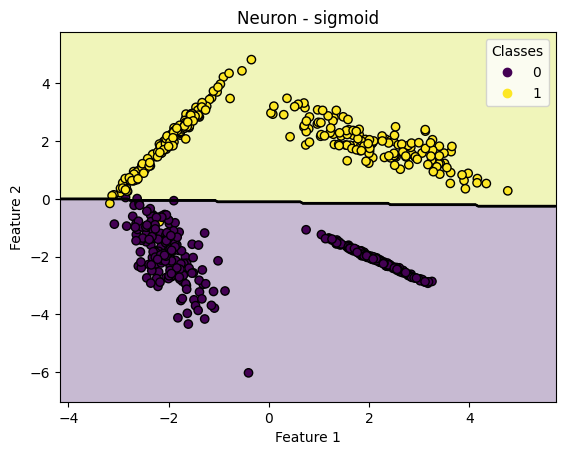

In [17]:
neuron = Neuron(input_dim = X_train.shape[1], lr=0.1, activation='sigmoid')
neuron.fit(X_train, y_train, epochs=100)
y_pred = neuron.predict(X_test)
print(f"Accuracy: {np.mean(y_pred == y_test)}")
plot_decision_boundary(X_test, y_test, neuron, "Neuron - sigmoid")

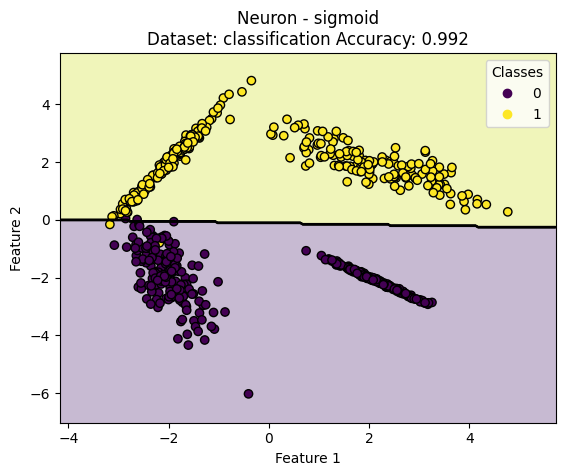

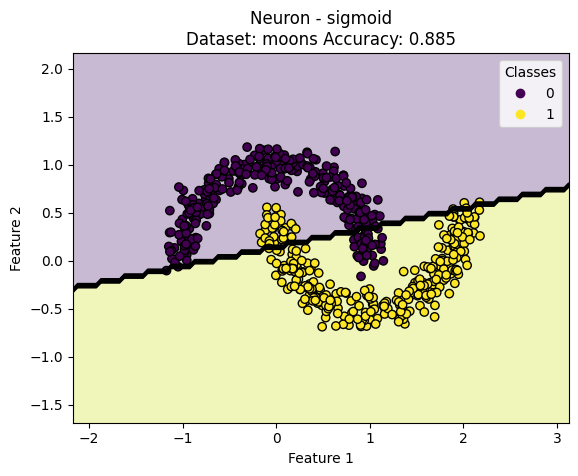

In [18]:
datasets = {
    'classification': (X_train, y_train, X_test, y_test),
    'moons': (Xm_train, ym_train, Xm_test, ym_test),
}
results = []

for ds_name, (X_tr, y_tr, X_te, y_te) in datasets.items():
    neuron = Neuron(input_dim = X_tr.shape[1], lr=0.1, activation='sigmoid')
    neuron.fit(X_tr, y_tr, epochs=100)
    y_pr = neuron.predict(X_te)
    y_sc = neuron.predict_proba(X_te)
    acc = np.mean(y_pr == y_te)
    plot_decision_boundary(X_te, y_te, neuron, f"Neuron - sigmoid\nDataset: {ds_name} Accuracy: {acc:.3f}")
    results.append({
            'activation': 'sigmoid',
            'dataset': ds_name,
            'accuracy': acc,
            'model': neuron,
            'y_pred': y_pr,
            'y_score': y_sc,
            'y_true': y_te
        })

# Evaluation

In [19]:
pd.DataFrame(results).drop(columns=['y_pred','y_score', 'y_true', 'model']).sort_values(by=['accuracy'], ascending=False)

,activation,dataset,accuracy
0,sigmoid,classification,0.992013
1,sigmoid,moons,0.884984


In [21]:
times = []

for row in results:
    ds_name = row['dataset']
    model = row['model']

    X_tr, y_tr = datasets[ds_name][0:2]

    iterations = 10
    t0 = time.time()
    for _ in range(iterations):
        model.fit(X_tr, y_tr)
    t1 = time.time() - t0

    times.append({
        'activation': row['activation'],
        'dataset': ds_name,
        'time': t1/iterations,
    })

In [22]:
times_df = pd.DataFrame(times)
times_df.sort_values(by=['time'], ascending=False)

,activation,dataset,time
0,sigmoid,classification,0.782054
1,sigmoid,moons,0.766858


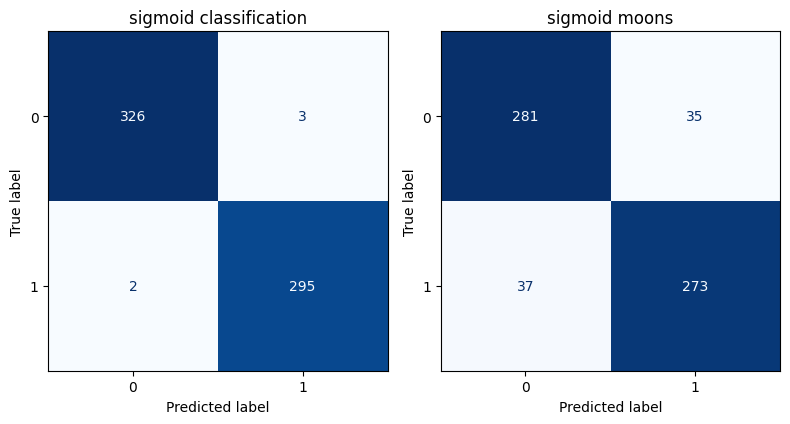

In [26]:
cms = {}
fig, axes = plt.subplots(1, 2, figsize=(8, 10))
axes = axes.flatten()
for i, row in enumerate(results):
    cm = confusion_matrix(row['y_true'], row['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    cm_title = f"{row['activation']} {row['dataset']}"
    axes[i].set_title(cm_title)
    cms[cm_title] = cm
    
plt.tight_layout()
plt.show()

In [28]:
stats_df = pd.DataFrame(columns=['dataset', 'activation', 'specificity', 'sensitivity'])

for cm_name, cm_matrix in cms.items():
    parts = cm_name.split()
    dataset = parts[0]
    activation_type = parts[1]

    tn, fp, fn, tp = cm_matrix.ravel()
    specificity = tn / (tn+fp) if (tn+fp) > 0 else 0
    sensitivity = tp / (tp+fn) if (tp+fn) > 0 else 0

    stats_df.loc[len(stats_df)] = [activation_type, dataset, specificity, sensitivity]

stats_df = stats_df.round(3)
stats_df

,dataset,activation,specificity,sensitivity
0,classification,sigmoid,0.991,0.993
1,moons,sigmoid,0.889,0.881


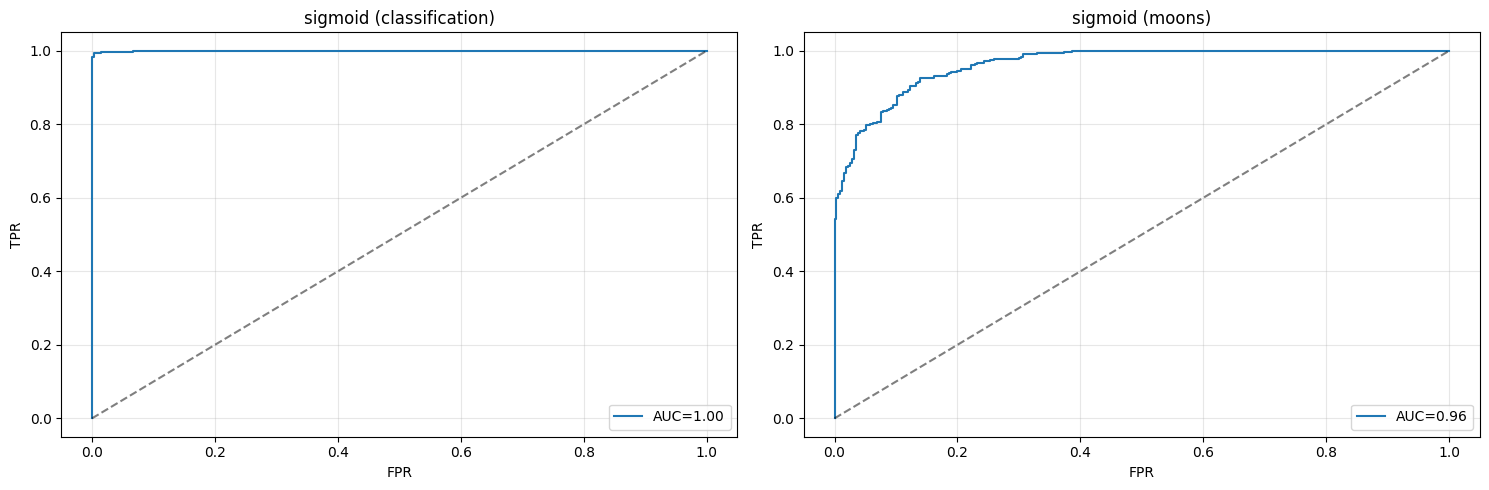

In [32]:
n_plots = len(results)
n_cols = 2
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, row in enumerate(results):
    if i >= len(axes):
        break

    activation_type = row['activation']
    dataset = row['dataset']
    y_true = row['y_true']
    y_score = row['y_score']

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    axes[i].plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
    axes[i].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[i].set_title(f"{activation_type} ({dataset})")
    axes[i].set_xlabel("FPR")
    axes[i].set_ylabel("TPR")
    axes[i].legend(loc="lower right")
    axes[i].grid(alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()